# Summarizing Messages

### Set the OpenAI API Key as an Environment Variable

In [1]:
import os

GROQ_API_KEY = input("Enter your Groq API key: ").strip()
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
print("API key set successfully!")

API key set successfully!


### Import Relevant Classes and Functions

In [24]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, RemoveMessage
from typing import Literal
import uuid

### Define the State

In [25]:
class State(MessagesState):
    summary: str
    message_count: int

In [4]:
test_state = State()

print("Summary value:", test_state.get("summary", ""))
print("Is summary present?", bool(test_state.get("summary", "")))

Summary value: 
Is summary present? False


### Define the Nodes

In [16]:
chat = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=1000,
    timeout=60,
)

In [26]:
def create_message_with_id(msg_type, content, msg_id=None):
    """Create a message with a proper ID"""
    if msg_type == "human":
        msg = HumanMessage(content=content)
    elif msg_type == "ai":
        msg = AIMessage(content=content)
    else:
        msg = SystemMessage(content=content)

    # Assign ID if not present
    if not hasattr(msg, 'id') or not msg.id:
        msg.id = msg_id or str(uuid.uuid4())
    return msg

In [27]:
def ask_question(state: State) -> State:
    print(f"\n-------> ENTERING ask_question:")
    question = "What is your question?"
    print(question)
    user_input = input("> ").strip()

    # Create messages with IDs
    ai_msg = create_message_with_id("ai", question, f"ai_q_{state.get('message_count', 0)}")
    human_msg = create_message_with_id("human", user_input, f"human_{state.get('message_count', 0) + 1}")

    return State(
        messages=[ai_msg, human_msg],
        summary=state.get("summary", ""),
        message_count=state.get("message_count", 0) + 2
    )

In [28]:
def chatbot(state: State) -> State:
    print(f"\n-------> ENTERING chatbot:")

    # Show current summary if exists
    if state.get("summary"):
        print(f"Current summary: {state['summary']}")

    system_message = f'''
Here's a quick summary of what's been discussed so far:
{state.get("summary", "")}

Keep this in mind as you answer the next question.
'''

    # Get response
    response = chat.invoke([SystemMessage(content=system_message)] + state["messages"])

    # Create response with ID
    response_msg = create_message_with_id("ai", response.content, f"ai_resp_{state.get('message_count', 0)}")

    print(f"Assistant: {response.content}")

    return State(
        messages=[response_msg],
        summary=state.get("summary", ""),
        message_count=state.get("message_count", 0) + 1
    )


In [29]:
def ask_another_question(state: State) -> State:
    print(f"\n-------> ENTERING ask_another_question:")
    question = "Would you like to ask one more question (yes/no)?"
    print(question)
    user_input = input("> ").strip().lower()

    # Create messages with IDs
    ai_msg = create_message_with_id("ai", question, f"ai_another_{state.get('message_count', 0)}")
    human_msg = create_message_with_id("human", user_input, f"human_another_{state.get('message_count', 0) + 1}")

    return State(
        messages=[ai_msg, human_msg],
        summary=state.get("summary", ""),
        message_count=state.get("message_count", 0) + 2
    )


In [30]:
def summarize_conversation(state: State) -> State:
    print(f"\n-------> ENTERING summarize_conversation:")

    # Build conversation text
    conversation = ""
    for msg in state["messages"]:
        conversation += f"{msg.type}: {msg.content}\n"

    summary_prompt = f'''
Update the ongoing summary by incorporating the new conversation below.

Previous Summary:
{state.get("summary", "")}

New Conversation:
{conversation}

Provide an updated summary (2-3 sentences):
'''

    summary_response = chat.invoke([HumanMessage(content=summary_prompt)])
    new_summary = summary_response.content

    print(f"\nUpdated Summary: {new_summary}")

    # IMPORTANT: Don't delete messages, just keep them and update summary
    # This avoids the ID deletion issue entirely
    return State(
        messages=state["messages"],  # Keep all messages
        summary=new_summary,
        message_count=state.get("message_count", 0)
    )

### Define the Routing Function

In [31]:
def routing_function(state: State) -> Literal["summarize_conversation", "__end__"]:
    # Check last human message
    for msg in reversed(state["messages"]):
        if msg.type == "human":
            if msg.content == "yes":
                return "summarize_conversation"
            else:
                return "__end__"
    return "__end__"

### Define the Graph

In [33]:
graph = StateGraph(State)

In [34]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another", ask_another_question)
graph.add_node("summarize_conversation", summarize_conversation)

# Add edges
graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges("ask_another", routing_function)
graph.add_edge("summarize_conversation", "ask_question")

In [35]:
graph_compiled = graph.compile()

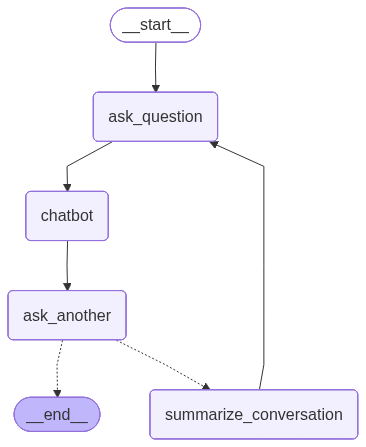

In [36]:
graph_compiled

### Test the Graph

In [38]:
print("\n" + "="*50)
print("Starting Chatbot with Message Summarization")
print("="*50)
print("Type your questions. Say 'yes' when prompted to continue with summary.")
print("Say 'no' to exit.\n")

try:
    result = graph_compiled.invoke(State(messages=[], summary="", message_count=0))

    print("\n" + "="*50)
    print("Chat session completed!")
    print("="*50)

    if result and "summary" in result and result["summary"]:
        print("\nFinal Summary:")
        print(result["summary"])
    else:
        print("\nNo summary generated.")

except Exception as e:
    print(f"\nError: {e}")


Starting Chatbot with Message Summarization
Type your questions. Say 'yes' when prompted to continue with summary.
Say 'no' to exit.


-------> ENTERING ask_question:
What is your question?

-------> ENTERING chatbot:
Assistant: It seems we just started our conversation, and there's no context or previous discussion to draw from. How can I assist you today?

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?

-------> ENTERING summarize_conversation:

Updated Summary: The conversation has just begun, with the human greeting the AI and the AI responding by acknowledging the start of their conversation. The human has not yet asked a question, but has indicated a desire to do so by responding "yes" when asked if they would like to ask a question. The conversation is currently at the initial stage, with the AI waiting for the human's first question.

-------> ENTERING ask_question:
What is your question?

-------> ENTERING chatbot:
Current summary: T

In [39]:
# ----------------------------
#  View Final Summary
# ----------------------------
print("\nFinal Summary:")
print(result.get("summary", "No summary generated"))


Final Summary:
The conversation has just begun, with the human greeting the AI and the AI responding by acknowledging the start of their conversation. The human has not yet asked a question, but has indicated a desire to do so by responding "yes" when asked if they would like to ask a question. The conversation is currently at the initial stage, with the AI waiting for the human's first question.


In [40]:
# ----------------------------
#  Simple Interactive Version (without graph)s
# ----------------------------
print("\n" + "="*50)
print("Simple Interactive Chat with Summary")
print("="*50)
print("Type 'quit' to exit\n")

# Simple implementation without the graph complexity
simple_chat = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.7,
    max_tokens=200,
    timeout=60,
)

conversation_history = []
summary = ""

while True:
    user_input = input("\nYou: ").strip()
    if user_input.lower() == 'quit':
        break

    # Add user message to history
    conversation_history.append(HumanMessage(content=user_input))

    # Prepare messages with summary context
    messages = []
    if summary:
        messages.append(SystemMessage(content=f"Previous conversation summary: {summary}"))
    messages.extend(conversation_history[-6:])  # Last 6 messages for context

    # Get response
    response = simple_chat.invoke(messages)
    print(f"Assistant: {response.content}")

    # Add response to history
    conversation_history.append(response)

    # Periodically summarize (every 4 messages)
    if len(conversation_history) >= 8:
        summary_prompt = f'''
        Summarize the following conversation concisely:

        {chr(10).join([f"{m.type}: {m.content}" for m in conversation_history])}

        Previous summary: {summary}

        Provide an updated summary:
        '''

        summary_response = simple_chat.invoke([HumanMessage(content=summary_prompt)])
        summary = summary_response.content
        print(f"\n[Summary updated: {summary}]\n")

        # Clear old messages but keep recent ones
        conversation_history = conversation_history[-4:]

print("Goodbye!")


Simple Interactive Chat with Summary
Type 'quit' to exit

Assistant: It's nice to meet you. Is there something I can help you with or would you like to chat?
Assistant: Walter White, also known as Heisenberg, is the main character from the popular TV series Breaking Bad. He's a high school chemistry teacher turned meth kingpin, played by Bryan Cranston. The show explores his transformation from a struggling family man to a ruthless and calculating individual driven by his desire for power, money, and control.

What's your interest in Walter White? Are you a fan of the show, or is there something specific you'd like to know about his character?
Assistant: As a digital being, I don't have a physical body, so I don't have the ability to cook in the classical sense. However, I can provide you with recipes, cooking instructions, and tips on how to prepare a wide variety of dishes!

If you're looking for a specific recipe or have a particular cuisine in mind, feel free to let me know and I'